# Convolutional Neural Networks

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
import numpy as np
import pandas as pd
import os.path
import subprocess
import matplotlib.collections
import scipy.signal
from sklearn import model_selection
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Use CPU rather than GPU for keras neural networks
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import tensorflow as tf
from tensorflow import keras
from tqdm.keras import TqdmCallback


2026-02-24 01:04:38.498178: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-24 01:04:38.520085: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-24 01:04:38.969064: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## <span style="color:Orange">Convolutional Networks</span>

A _<span style="color:Violet">Convolutional Neural Network</span>_ (CNN) is a special architecture that:
 - Assumes that input features measure some property on a grid. The grid is usually spatial or temporal, but this is not required. For example, a 1D spectrum or time series, a 2D monochrome image, or a 3D stack of 2D images in different filters (RGB, etc).

 - Performs translation-invariant learning efficiently. For example, identifying a galaxy wherever it appears in an image, or a transient pulse wherever it appears in a time series. The main efficiency is a much reduced number of parameters compared to the number of input features, relative to the dense fully connected networks we have seen so far.

As we saw in the previous lecture, Neural Networks receive an input (a single vector), and transform it through a series of hidden layers. Each hidden layer is made up of a set of neurons, where each neuron is fully connected to all neurons in the previous layer, and where neurons in a single layer function completely independently and do not share any connections. The last fully-connected layer is called the “output layer” and in classification settings it represents the class scores.

The fully-connected, feed-forward neural networks we have studied thus far do not scale well to large image data. For example, a modest 200 $\times$ 200 $\times$ 3 (x-pixels, y-pixels, 3 colors) image would lead to neurons that have 200 $\times$ 200 $\times$ 3 = 120,000 weights. Moreover, we would almost certainly want to have several such neurons, so the parameters would add up quickly! Clearly, this full connectivity is wasteful and the huge number of parameters would quickly lead to overfitting.

Convolutional Neural Networks take advantage of the fact that the input consists of images and they constrain the architecture in a more sensible way to reduce the number of parameters. In particular, unlike a regular Neural Network, the layers of a CNN have neurons arranged in 3 dimensions: width, height, depth. 

(Note that the word "depth" here refers to the third dimension of an activation volume, not to the depth of a full Neural Network, which can refer to the total number of layers in a network...) 

The neurons in a CNN layer will only be connected to a small region of the layer before it, instead of all of the neurons in a fully-connected manner.

A CNN is made up of layers of different types (convolutions, pooling, fully-connected), in general. Every layer has a simple API: It transforms an input 3D volume to an output 3D volume with some differentiable function that may or may not have parameters.

We will use the following problem to motivate and demonstration a CNN:

 - The input data consists of triplets of digitized waveforms.

 - Each waveform has a slowly varying level with some narrow pulses superimposed.

 - Each triplet has a single pulse that is synchronized (coincident) in all three waveforms.

 - Waveforms also contain a random number of unsynchronized "background" pulses.

 - Synchronized and unsynchronized pulses can overlap in time and between traces.

The goal is to identify the location of the synchronized pulses in each triplet. This is a simplified version of a common task in data acquisition trigger systems and transient analysis pipelines.

In [3]:
def generate(N=10000, ntrace=3, nt=100, nbg=1., A=5., nsmooth=3, T=1., seed=123):
    gen = np.random.RandomState(seed=seed)
    t_grid = np.linspace(0., T, nt)
    # Generate the smooth background shapes as superpositions of random cosines.
    wlen = 2 * T * gen.lognormal(mean=0., sigma=0.2, size=(nsmooth, N, ntrace, 1))
    phase = gen.uniform(size=wlen.shape)
    X = np.cos(2 * np.pi * (t_grid + phase * wlen) / wlen).sum(axis=0)
    # Superimpose short pulses.
    sigma = 0.02 * T
    tsig = T * gen.uniform(0.05, 0.95, size=N)
    y = np.empty(N, dtype=int)
    nbg = gen.poisson(lam=nbg, size=(N, ntrace))
    for i in range(N):
        # Add a coincident pulse to all traces.
        xsig = A * np.exp(-0.5 * (t_grid - tsig[i]) ** 2 / sigma ** 2)
        y[i] = np.argmax(xsig)
        X[i] += xsig
        # Add non-coincident background pulses to each trace.
        for j in range(ntrace):
            if nbg[i, j] > 0:
                t0 = T * gen.uniform(size=(nbg[i, j], 1))
                X[i, j] += (A * np.exp(-0.5 * (t_grid - t0) ** 2 / sigma ** 2)).sum(axis=0)
    return X.astype(np.float32), y

X, y = generate()

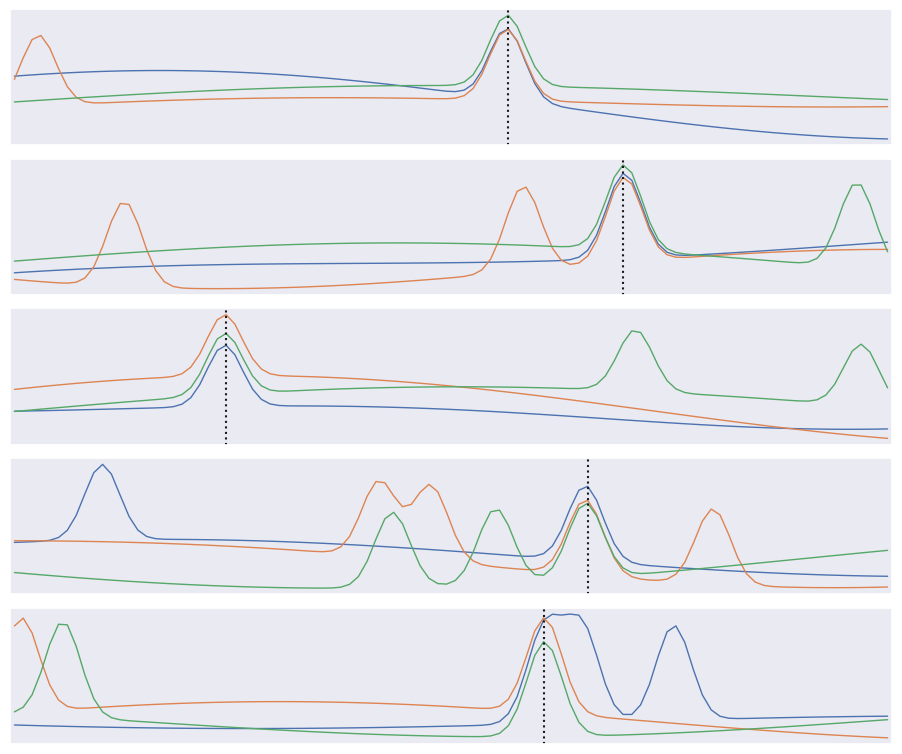

In [4]:
def plot_traces(X, y):
    Nsample, Ntrace, D = X.shape
    _, ax = plt.subplots(Nsample, 1, figsize=(9, 1.5 * Nsample))
    t = np.linspace(0., 1., 100)
    dt = t[1] - t[0]
    for i in range(Nsample):
        for j in range(Ntrace):
            ax[i].plot(t, X[i, j], lw=1)
        ax[i].axvline(t[y[i]], c='k', ls=':')
        ax[i].set_yticks([])
        ax[i].set_xticks([])
        ax[i].set_xlim(-0.5 * dt, 1 + 0.5 * dt)
    plt.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.99, hspace=0.1)

plot_traces(X[:5], y[:5])

The derivative of $f(x)$ can be approximated as

$$ \Large
f'(x) \simeq \frac{f(x + \delta) - f(x - \delta)}{2\delta}
$$

for small $\delta$. We can use this approximation to convert an array of $f(n \Delta x)$ values into an array of estimated $f'(n \Delta x)$ values using:
```
K = np.array([-1, 0, +1]) / ( 2 * dx)
fp[0] = K.dot(f[[0,1,2]])
fp[1] = K.dot(f[[1,2,3]])
...
fp[N-2] = K.dot(f[[N-3,N-2,N-1]]
```
The numpy [convolve function](https://docs.scipy.org/doc/numpy-1.14.0/reference/generated/numpy.convolve.html) automates this process of sliding an arbitrary <span style="color:Violet">kernel</span> $K$ along an input array like this. The result only estimates a first (or higher-order) derivative when the kernel contains [special values](https://en.wikipedia.org/wiki/Finite_difference_coefficient) (and you should normally use the numpy [gradient function](https://docs.scipy.org/doc/numpy-1.14.0/reference/generated/numpy.gradient.html) for this), but any convolution is a valid and potentially useful transformation.

A clarifying word about terminology: In the context of convolutional networks, <span style="color:Violet">kernel</span> is a simple group of weights shared all over the input space that is engineered to determine what specific features are to be detected. The kernel is also sometimes referred to as a "feature map" or "filter" in this context.

See for example the application of a kernel in convolution over a simple black-and-white image:
[here](https://i.stack.imgur.com/9Iu89.gif).


The kernel needs to completely overlap the input array it is being convolved with, which means that the output array is smaller and offset. Alternatively, you can pad the input array with zeros to extend the output array. There are three different conventions for handling these edge effects via the `mode` parameter to `np.convolve`:
 - **valid**: no zero padding, so output length is $N - K + 1$ and offset is $(K-1)/2$.

 - **same**: apply zero padding and trim so output length equals input length $N$, and offset is zero.

 - **full**: apply zero padding without trimming, so output length is $N + K - 1$ and offset is $-(K-1)/2$.

(Here $N$ and $K$ are the input and kernel lengths, respectively).

We can use a convolution to identify features in our input data:

In [5]:
def plot_convolved(x, kernel, smax=50):
    t = np.arange(len(x))
    plt.plot(t, x, lw=1, c='gray')
    z = np.convolve(x, kernel, mode='same')
    for sel, c in zip(((z > 0), (z < 0)), 'rb'):
        plt.scatter(t[sel], x[sel], c=c, s=smax * np.abs(z[sel]), lw=0)
    plt.gca()
    plt.grid(False)

First, let's pick out regions of large positive (red) or negative slope (notice how the edge padding causes some artifacts):

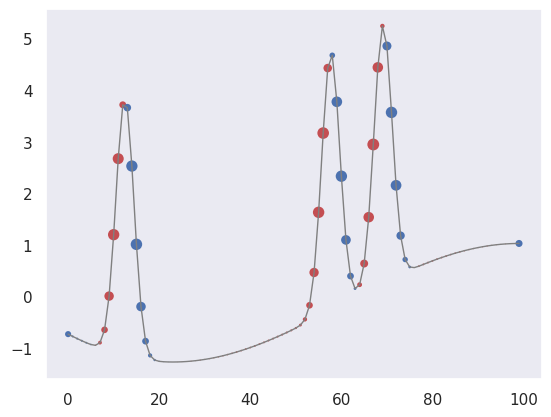

In [6]:
plot_convolved(X[1, 1], [0.5,0,-0.5])

We can also pick out regions of large curvature (using the finite-difference coefficients for a second derivative):

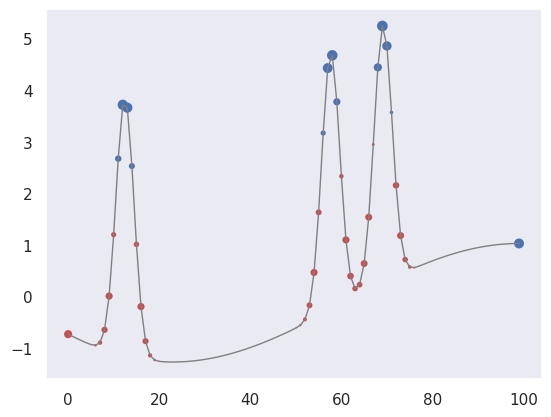

In [7]:
plot_convolved(X[1, 1], [1.,-2.,1.])

We can apply both of these convolutions to transform our input data to a new representation that highlights regions of large first or second derivative. Use a `tanh` activation to accentuate the effect:

In [8]:
def apply_convolutions(X, *kernels):
    N1, N2, D = X.shape
    out = []
    for i in range(N1):
        sample = []
        for j in range(N2):
            for K in kernels:
                sample.append(np.tanh(np.convolve(X[i, j], K, mode='valid')))
        out.append(sample)
    return np.asarray(out)

In [9]:
out = apply_convolutions(X, [0.5,0,-0.5], [1.,-2.,1.])

The resulting array can be viewed as a synthetic image and offers an easy way to visually identify individual narrow peaks and their correlations between traces:

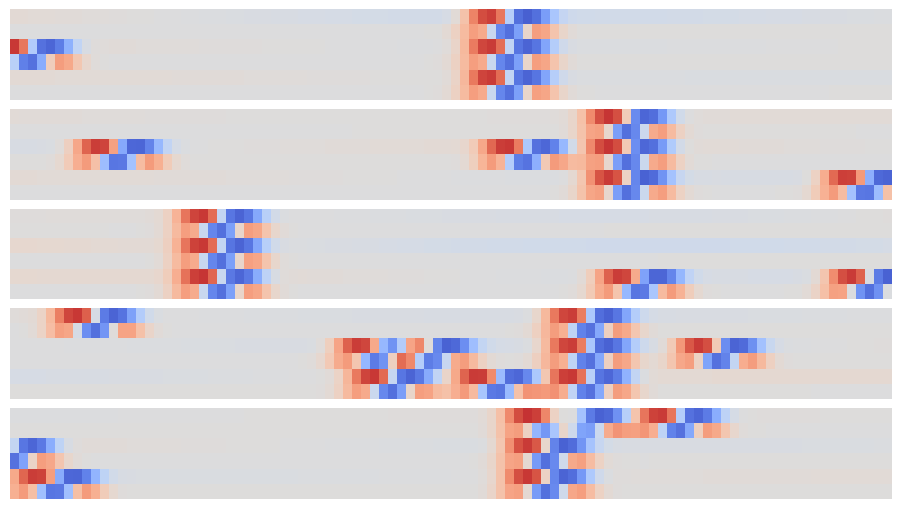

In [10]:
def plot_synthetic(Z):
    _, ax = plt.subplots(len(Z), 1, figsize=(9, len(Z)))
    for i, z in enumerate(Z):
        ax[i].imshow(z, aspect='auto', origin='upper', interpolation='none',
                   cmap='coolwarm', vmin=-1, vmax=+1);
        ax[i].grid(False)
        ax[i].axis('off')
    plt.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.99, hspace=0.1)

plot_synthetic(out[:5])

The patterns that identify individual and coincident peaks are all translation invariant so can be identified in this array using a new convolution, but now in the 2D space of these synthetic images.

Since matrix convolution is a linear operation, it is a special case of our general neural network unit,

$$ \Large
\mathbf{f}(\mathbf{x}) = W\mathbf{x} + \mathbf{b} \; ,
$$

but with the matrix $W$ now having many repeated elements so its effective number of dimensions is greatly reduced in typical applications.

A <span style="color:Violet">convolutional layer</span> takes an arbitrary input array and applies a number of filters with the same shape in parallel. By default, the filter kernels march with single-element steps through the input array, but you can also specify larger <span style="color:Violet">stride vector</span>.

In the general case, the input array, kernels and stride vector are all multidimensional, but with the same dimension. Tensorflow provides convenience functions for 1D, 2D and 3D convolutional layers, for example:
```
hidden = keras.layers.Conv2D(
    filters=3, kernel_size=[4, 5], strides=[2, 1],
    padding='same', activation='relu')
```
Note that `padding` specifies how edges effects are handled, but only `same` and `valid` are supported (and `valid` is the default). You can also implement higher-dimensional convolutional layers using the lower-level APIs.

A _<span style="color:Violet">convolutional neural network</span>_ (CNN) is a network containing convolutional layers. A typical architecture starts with convolutional layers, processing the input, then finishes with some fully connected dense layers to calculate the output. Since one of the goals of a CNN is reduce the number of parameters, a CNN often also incorporates [pooling layers](https://en.wikipedia.org/wiki/Convolutional_neural_network#Pooling_layer) to reduce the size of the array fed to to later layers by "downsampling" (typically using a maximum or mean value). See [these Stanford CS231n notes](http://cs231n.github.io/convolutional-networks/) for more details in the context of image classification.

In [11]:
def build_pulse_model(params):
    """Build a tf.keras model for pulse coincidence detection."""
    D = params['time_steps']
    M = params['number_of_traces']
    n1 = params['conv1_width']
    n2 = params['conv2_width']
    eta = params['learning_rate']
    assert n1 % 2 == 1 and n2 % 2 == 1

    inputs = keras.Input(shape=(M, D), name='X')
    x = keras.layers.Reshape((M, D, 1))(inputs)
    x = keras.layers.Conv2D(
        filters=2, kernel_size=(1, n1),
        padding='same', activation='tanh', name='conv1')(x)
    logits = keras.layers.Conv2D(
        filters=1, kernel_size=(M, n2),
        padding='valid', activation=None, name='conv2')(x)
    logits = keras.layers.Reshape((D - n2 + 1,), name='logits')(logits)

    model = keras.Model(inputs=inputs, outputs=logits, name='pulse')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=eta),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')])
    return model


In [12]:
print(tf.__version__)

# Keep runs reproducible.
keras.utils.set_random_seed(123)


2.20.0


In [13]:
params = dict(
    time_steps=100,
    number_of_traces=3,
    conv1_width=3,
    conv2_width=7,
    learning_rate=0.01)

offset = (params['conv2_width'] - 1) // 2


In [14]:
pulse = build_pulse_model(params)
pulse.summary()


2026-02-24 01:04:39.623169: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-02-24 01:04:39.623200: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES=""
2026-02-24 01:04:39.623208: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to an empty string - this hides all GPUs from CUDA
2026-02-24 01:04:39.623210: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-02-24 01:04:39.623214: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: sob
2026-02-24 01:04:39.623215: I external/local_xla/xla/stream_executor/cud

Model: "pulse"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ X (InputLayer)                  │ (None, 3, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 100, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 3, 100, 2)      │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 1, 94, 1)       │            43 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Reshape)                │ (None, 94)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.4, random_state=123)


In [16]:
y_train_shifted = y_train - offset
y_test_shifted = y_test - offset


In [17]:
history = pulse.fit(
    X_train,
    y_train_shifted,
    batch_size=500,
    epochs=15,
    shuffle=True,
    verbose=0,
    callbacks=[TqdmCallback(verbose=1)])


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Evaluate how well the trained network performs on the test data:

In [18]:
test_loss, test_accuracy = pulse.evaluate(X_test, y_test_shifted, verbose=0)
logits = pulse.predict(X_test, verbose=0)
probs = tf.nn.softmax(logits, axis=-1).numpy()
bins = np.arange(logits.shape[1], dtype=np.float32) + offset
mean_labels = np.sum(probs * bins[None, :], axis=1)
rmse = np.sqrt(np.mean((mean_labels - y_test.astype(np.float32)) ** 2))

results = {
    'loss': float(test_loss),
    'accuracy': float(test_accuracy),
    'rmse': float(rmse)
}


We find that about 91% of test samples are classified "correctly", defined as the network predicting the bin containing the the coincidence maximum exactly.  However, The RMS error between the predicted and true bins is only 0.4 bins, indicating that the network usually predicts a neighboring bin in the 5% of "incorrect" test cases.

In [19]:
results

{'loss': 0.30110910534858704,
 'accuracy': 0.9110000133514404,
 'rmse': 0.6199796199798584}

Finally, compare the predicted (gray histogram) and true (dotted line) coincidence locations for a few test samples:

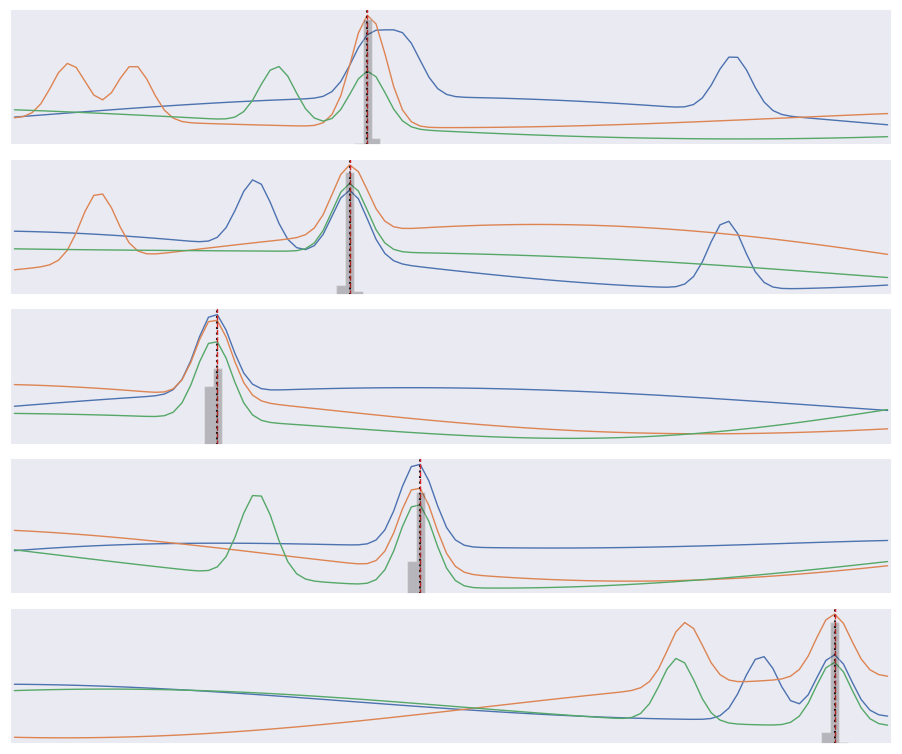

In [20]:
def plot_predictions(X, y):
    logits = pulse.predict(X, verbose=0)
    pred_probs = tf.nn.softmax(logits, axis=-1).numpy()
    pred_labels = np.argmax(pred_probs, axis=1) + offset

    Nsample, Ntrace, D = X.shape
    t = np.linspace(0., 1., 100)
    dt = t[1] - t[0]
    bins = np.linspace(-0.5 * dt, 1 + 0.5 * dt, len(t) + 1)

    # Plot input data, truth, and predictions.
    _, ax = plt.subplots(Nsample, 1, figsize=(9, 1.5 * Nsample))
    for i in range(Nsample):
        # Plot the input traces.
        for x in X[i]:
            ax[i].plot(t, x, lw=1)

        # Indicate the true coincidence position.
        ax[i].axvline(t[y[i]], c='k', ls=':')

        # Indicate the predicted probability distribution.
        probs = np.zeros(D)
        pred = pred_probs[i]
        n2 = D - len(pred) + 1
        pad = (n2 - 1) // 2
        probs[pad:-pad] = pred

        # Indicate predicted best label.
        ax[i].axvline(t[pred_labels[i]], c='tab:red', ls='--', lw=1)

        rhs = ax[i].twinx()
        rhs.hist(t, weights=probs, bins=bins, histtype='stepfilled', alpha=0.25, color='k')
        rhs.set_ylim(0., 1.)
        rhs.set_xlim(bins[0], bins[-1])
        rhs.set_yticks([])
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        ax[i].grid(False)
        ax[i].set_xlim(bins[0], bins[-1])

    plt.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.99, hspace=0.1)

plot_predictions(X_test[:5], y_test[:5])


Note that our loss function does not know that consecutive labels are close and being off by one is almost as good as getting the right label. We could change this by treating this as a regression problem, but a nice feature of our multi-category approach is that we can predict a a full probability density over labels (the gray histograms above) which is often useful.

## <span style="color:Orange">Acknowledgments</span>

* Initial version: Mark Neubauer

© Copyright 2026